## Week 9 Instructor-led Lab: Descriptive Statistics    
By: Dean Wilson  
Course: BGEN 632: Graduate Introduction to Python  
Date: 20250428  

In [1]:
# load modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts # for QQ plot
from scipy.stats import pearsonr # correlation p-values
from sklearn.linear_model import LinearRegression # regression output
import statsmodels.formula.api as smf # ols regression

In [3]:
# Set working directory
os.chdir("C:\\Users\\deanb\\OneDrive\\Desktop\\Python Graduate Class\\Week 9\\Week9labs-main\\Week9labs-main\\data")  

# Confirm current working directory
os.getcwd()  

'C:\\Users\\deanb\\OneDrive\\Desktop\\Python Graduate Class\\Week 9\\Week9labs-main\\Week9labs-main\\data'

### Data   

In [4]:
hospital_df = pd.read_csv('CaliforniaHospitalData.csv')
personnel_df = pd.read_table('CaliforniaHospitalData_Personnel.txt') # Opening files

### Merging Data

In [5]:
hospitalmerged_df = pd.merge(hospital_df, personnel_df, on='HospitalID', how='left') # Merge hospital_df and personnel_df on column HospitalID through hospitalmerged_df, had to use left to prevent columns from being delted

### Dropping Columns

In [6]:
hospitalmerged_df.drop(columns=['Work_ID', 'PositionID', 'Website'], inplace=True) # Dropped required columns and utilized inplace=True to ensure these changes are saved

### Adding Row

In [7]:
new_row = pd.DataFrame(
    {'LastName': ['Wilson'], 
     'FirstName': ['Dean'],
     'PositionTitle': ['Regional Representative'],
     'HospitalID': ['46996'],
     'Name': ['Ridgecrest Regional Hospital'],
     'Zip': ['93555'],
     'TypeControl': ['Non Profit'],
     'DonorType': ['Charity'],
     'Teaching': ['Small/Rural'],
     'NoFTE': [400],
     'NetPatRev': [139170.38],
     'InOperExp': [23385570.1],
     'OutOperExp': [24661355.9],
     'OperRev': [51087341],
     'OperInc': [3040415],
     'AvlBeds': [55],
     'Gender': ['M'],
     'Compensation': [23987],
     'MaxTerm': [2],
     'StartDate': ['4/28/2025'],
     'Phone': ['951-585-7892'],
     'Email': ['FakeEmail@gmail.com']
     
    }, # Added myself into the dataframe
)
first_merge = pd.concat([hospitalmerged_df, new_row], ignore_index=True) # New dataframe where we have stacked the new rows with hospitalnew_df
print(first_merge.tail())

   HospitalID                                               Name    Zip  \
57      31032   Long Beach Memorial & Miller Children's Hospital  90806   
58      22460                        Stanford Hospital & Clinics  94305   
59      33192  California Pacific Medical Center - Pacific Ca...  94115   
60      38900                        Cedars-Sinai Medical Center  90048   
61      46996                       Ridgecrest Regional Hospital  93555   

   TypeControl     Teaching DonorType   NoFTE    NetPatRev     InOperExp  \
57  Non Profit     Teaching    Alumni  5218.0  1187021.872  2.912481e+08   
58  Non Profit     Teaching    Alumni  6392.0  4333934.423  9.289621e+08   
59  Non Profit     Teaching    Alumni  1565.1  2736281.415  6.337903e+08   
60  Non Profit     Teaching    Alumni  8000.0  4662581.617  1.285631e+09   
61  Non Profit  Small/Rural   Charity   400.0   139170.380  2.338557e+07   

     OutOperExp  ...  AvlBeds  LastName  FirstName Gender  \
57  109328611.1  ...      462  

### Convert dates to datetime

In [8]:
first_merge['StartDate'] = pd.to_datetime(first_merge['StartDate']) # Convert any date-time columns into a datetime data type

### Converting to Categorical Data Type

In [9]:
categorical_cols = ['TypeControl', 'Teaching', 'DonorType', 'Gender'] # List categorical Columns

for col in categorical_cols: 
    first_merge[col] = first_merge[col].astype('category') # utilize a loop to convert each categorical column into category

print(first_merge.dtypes)

HospitalID               object
Name                     object
Zip                      object
TypeControl            category
Teaching               category
DonorType              category
NoFTE                   float64
NetPatRev               float64
InOperExp               float64
OutOperExp              float64
OperRev                   int64
OperInc                   int64
AvlBeds                   int64
LastName                 object
FirstName                object
Gender                 category
PositionTitle            object
Compensation              int64
MaxTerm                   int64
StartDate        datetime64[ns]
Phone                    object
Email                    object
dtype: object


### Descriptive Statisitics

In [10]:
first_merge.describe()

,NoFTE,NetPatRev,InOperExp,OutOperExp,OperRev,OperInc,AvlBeds,Compensation,MaxTerm,StartDate
count,62.000000,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,6.200000e+01,62.000000,62.000000,62.000000,62
mean,1334.937419,6.610285e+05,1.639660e+08,8.910169e+07,2.529639e+08,-1.038045e+05,192.274194,91665.241935,4.209677,2010-04-30 12:46:27.096774144
min,55.000000,1.417224e+04,1.436471e+06,3.787718e+06,5.235317e+06,-3.211633e+08,12.000000,23987.000000,2.000000,2002-01-01 00:00:00
25%,216.375000,7.284830e+04,1.382645e+07,1.429398e+07,2.685966e+07,-1.028922e+06,42.750000,46978.000000,3.000000,2009-04-02 06:00:00
50%,385.910000,1.670720e+05,3.124469e+07,3.259692e+07,6.153388e+07,1.615009e+06,99.000000,46978.000000,4.000000,2011-01-01 00:00:00
75%,1137.000000,5.317051e+05,1.639284e+08,8.867309e+07,1.982414e+08,6.146421e+06,228.250000,89473.000000,4.000000,2012-01-01 00:00:00
max,8000.000000,4.662582e+06,1.285631e+09,6.621559e+08,1.912179e+09,1.648724e+08,909.000000,248904.000000,8.000000,2025-04-28 00:00:00
std,2012.238339,1.090562e+06,2.810465e+08,1.364136e+08,4.222920e+08,7.095688e+07,220.719551,84302.035923,2.112702,NaN


In [11]:
first_merge.describe(include=['object'])

,HospitalID,Name,Zip,LastName,FirstName,PositionTitle,Phone,Email
count,62,62,62,62,62,62,62,62
unique,62,61,61,24,20,4,25,25
top,45740,Ridgecrest Regional Hospital,93555,Smith,David,Regional Representative,785-532-2452,david.web@comenitymed.com
freq,1,2,2,4,6,25,3,3


In [12]:
first_merge.describe(include=['category'])

,TypeControl,Teaching,DonorType,Gender
count,62,62,62,62
unique,4,2,2,2
top,Non Profit,Small/Rural,Charity,F
freq,38,45,45,32


<Axes: ylabel='Frequency'>

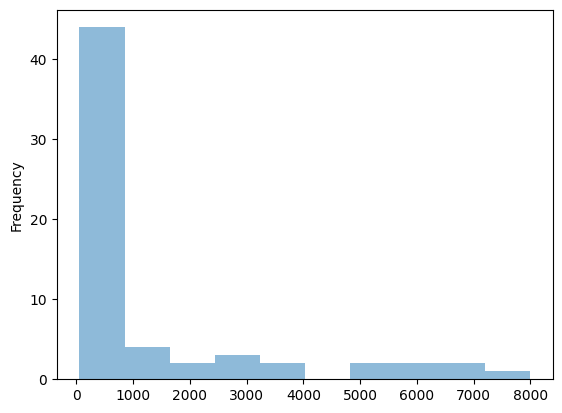

In [13]:
first_merge['NoFTE'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

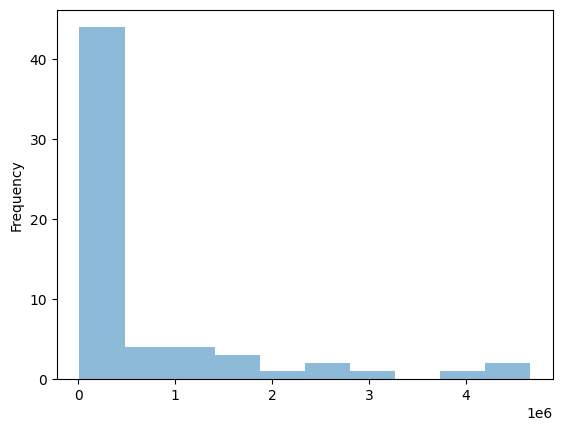

In [14]:
first_merge['NetPatRev'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

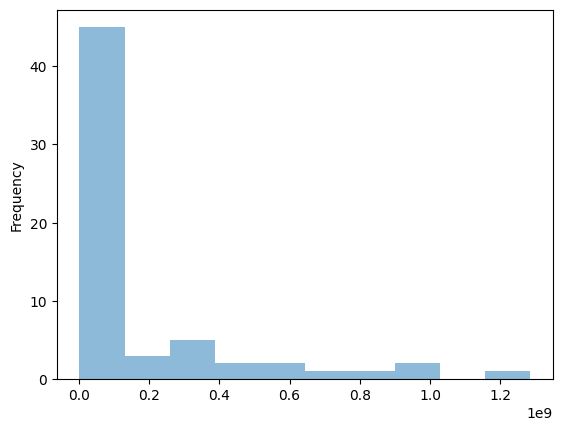

In [15]:
first_merge['InOperExp'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

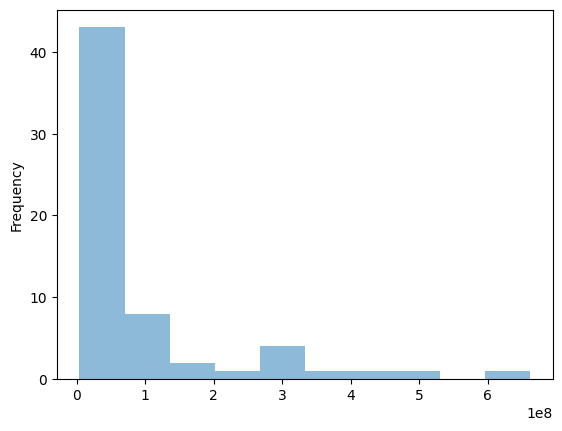

In [16]:
first_merge['OutOperExp'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

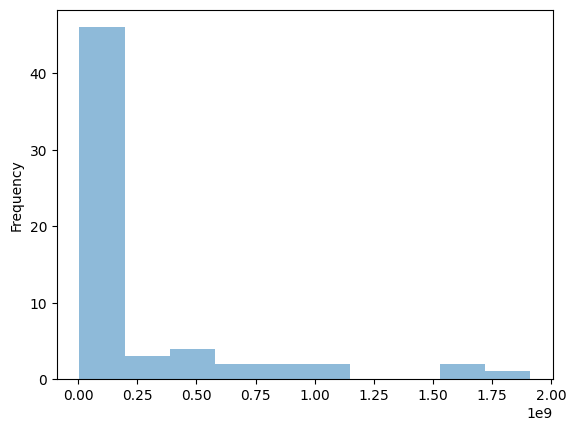

In [17]:
first_merge['OperRev'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

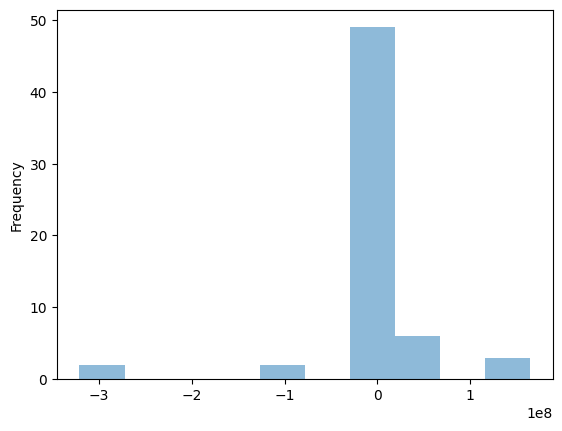

In [18]:
first_merge['OperInc'].plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

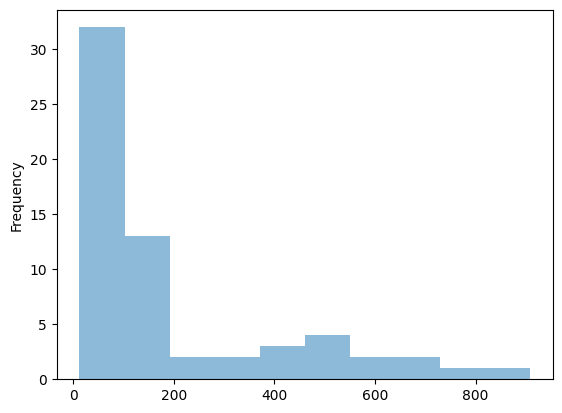

In [19]:
first_merge['AvlBeds'].plot.hist(alpha=0.5)

<Axes: xlabel='NoFTE', ylabel='NetPatRev'>

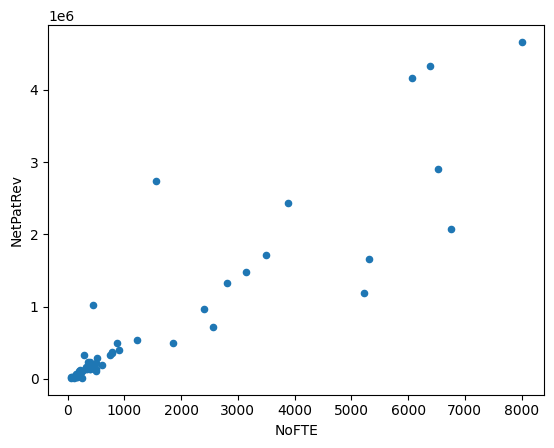

In [20]:
first_merge.plot.scatter(x='NoFTE', y='NetPatRev') # Appears to be semi-linear, and trending positively. As NoFTE increases, so does NetPatRev. More FTE = generally More Revenue

<Axes: xlabel='InOperExp', ylabel='NetPatRev'>

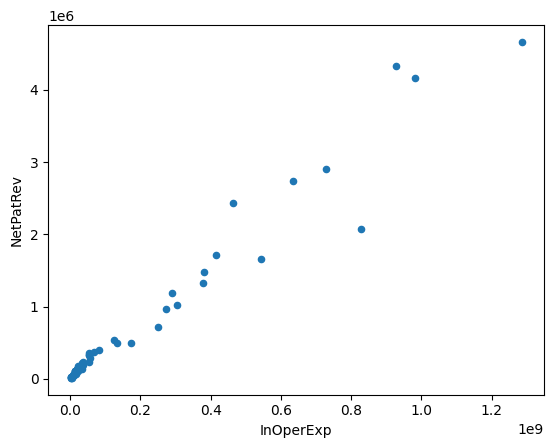

In [21]:
first_merge.plot.scatter(x='InOperExp', y='NetPatRev') # Appears to be semi-linear and trending positvely. As InOperExp increases, so does NetPatRev. Higher Inpatient Expense = generally higher revenue

<Axes: xlabel='OutOperExp', ylabel='NetPatRev'>

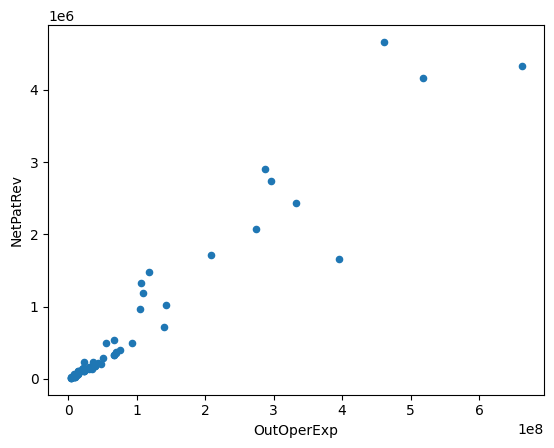

In [22]:
first_merge.plot.scatter(x='OutOperExp', y='NetPatRev') # Appears to be semi-linar, and trending positively. As OutOperExp increases, so does NetPatRev. Higher outpatient expesne = generally higher Net patient rev

<Axes: xlabel='OperRev', ylabel='NetPatRev'>

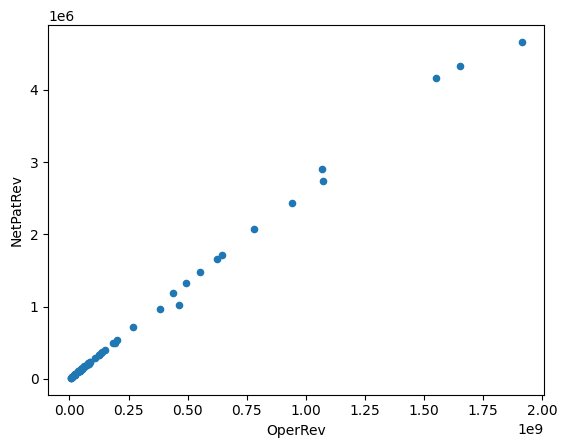

In [23]:
first_merge.plot.scatter(x='OperRev', y='NetPatRev') # Appears to be linear and trending positively. As OperRev increases, so does NetPatRev respectively

<Axes: xlabel='OperInc', ylabel='NetPatRev'>

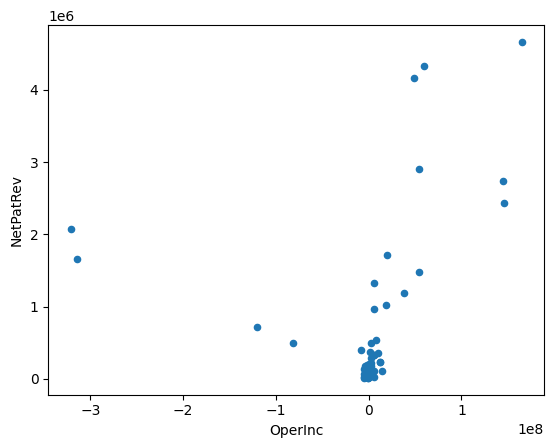

In [24]:
first_merge.plot.scatter(x='OperInc', y='NetPatRev') # Not linear at all, and appears to not be trending in any manner.

<Axes: xlabel='AvlBeds', ylabel='NetPatRev'>

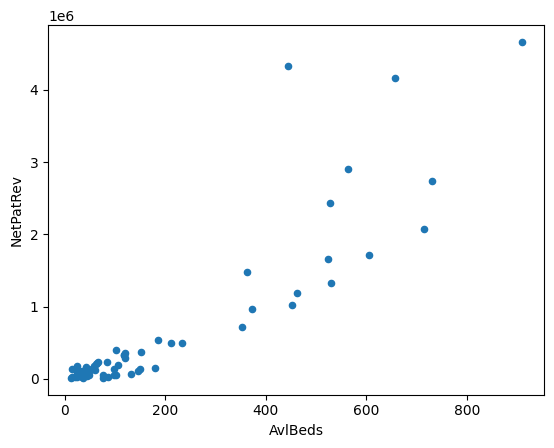

In [25]:
first_merge.plot.scatter(x='AvlBeds', y='NetPatRev') # Appears semi-linear and trending positively. As AvlBeds increase, so does NetPatRev. More beds = generally more revenue

<Axes: >

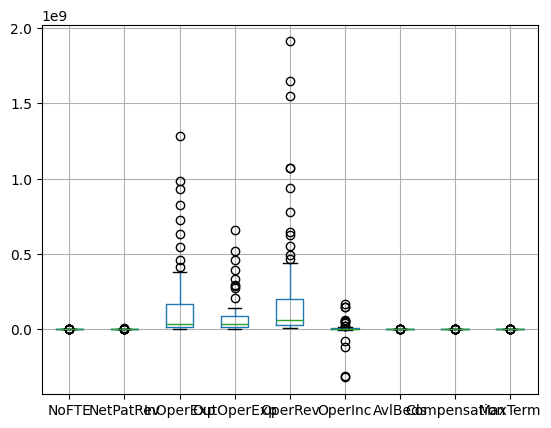

In [26]:
first_merge.boxplot() # Will be splitting up Variables due to range

<Axes: >

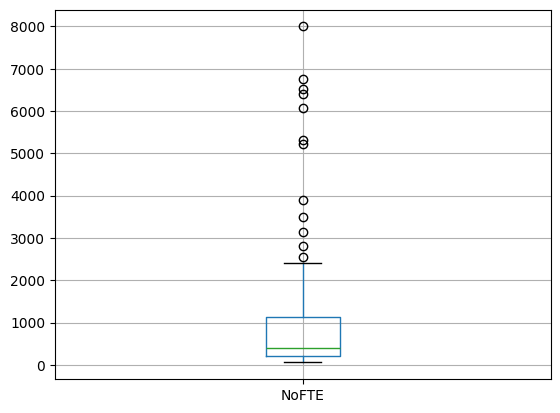

In [27]:
first_merge.loc[:,['NoFTE']].boxplot()

<Axes: >

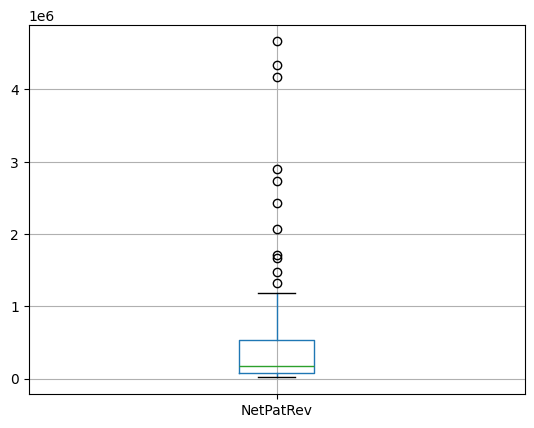

In [28]:
first_merge.loc[:,['NetPatRev']].boxplot()

<Axes: >

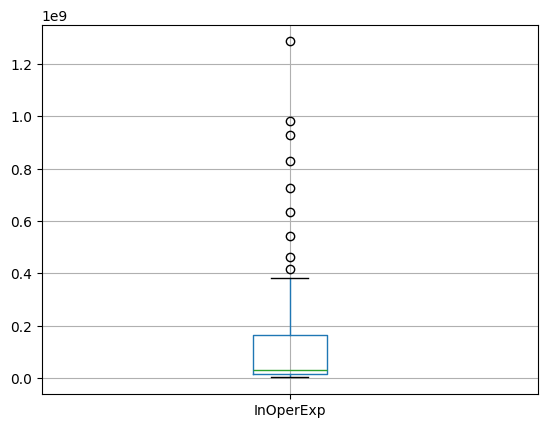

In [29]:
first_merge.loc[:,['InOperExp']].boxplot()

<Axes: >

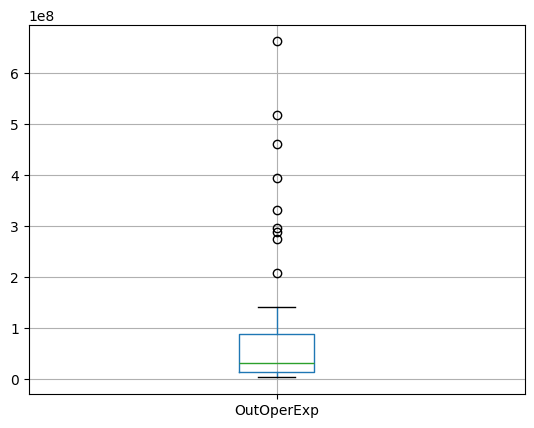

In [30]:
first_merge.loc[:,['OutOperExp']].boxplot()

<Axes: >

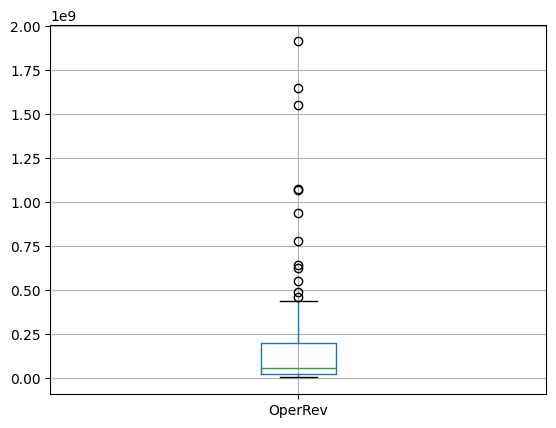

In [31]:
first_merge.loc[:,['OperRev']].boxplot()

<Axes: >

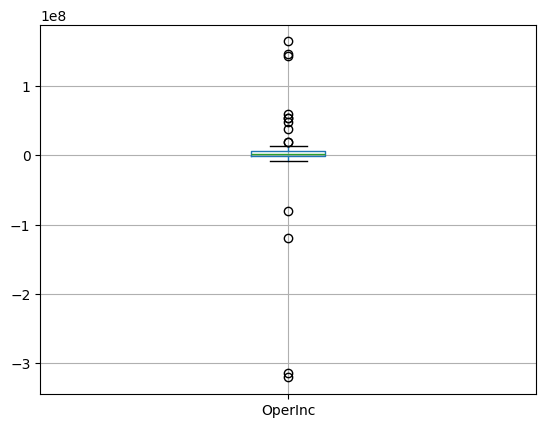

In [32]:
first_merge.loc[:,['OperInc']].boxplot()

<Axes: >

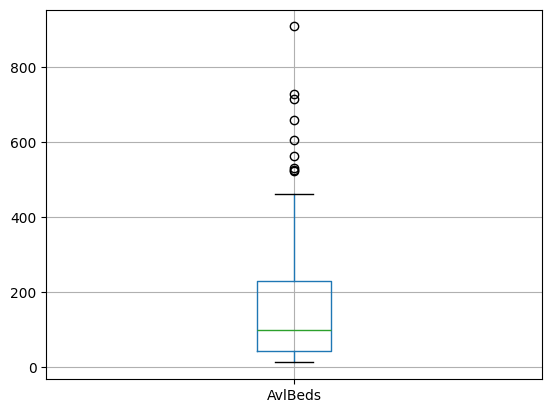

In [33]:
first_merge.loc[:,['AvlBeds']].boxplot()

((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([  55.  ,   67.  ,   75.  ,  100.  ,  121.  ,  150.  ,  158.  ,
   

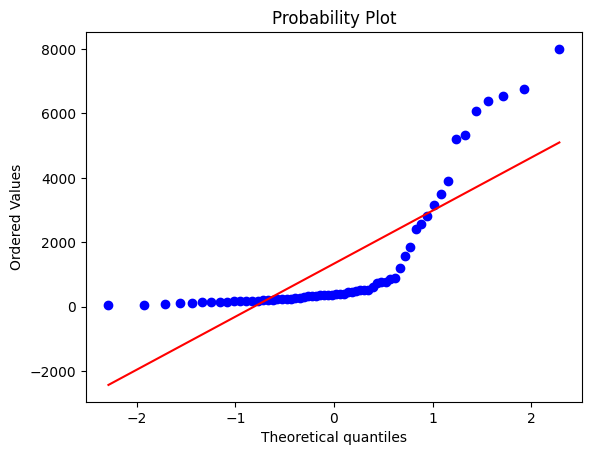

In [34]:
sts.probplot(first_merge['NoFTE'], dist="norm", plot=plt) # Distribution of NoFTE is skewed right

((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([   5235317,    5303740,    6677960,    9821366,   10751114,
      

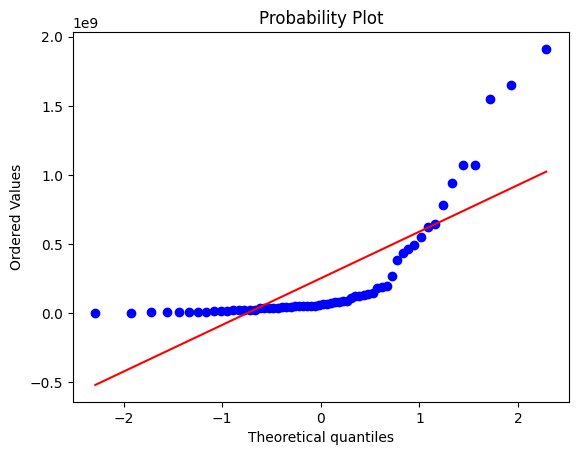

In [35]:
sts.probplot(first_merge['OperRev'], dist="norm", plot=plt) # Distribution of OperRev is skewed right

((array([-2.28632824, -1.92718526, -1.71674477, -1.56281938, -1.43895118,
         -1.33390917, -1.24182024, -1.15920615, -1.08382718, -1.01415101,
         -0.94907991, -0.88779833, -0.82968216, -0.77424185, -0.72108527,
         -0.6698925 , -0.6203983 , -0.57237956, -0.52564609, -0.48003374,
         -0.43539923, -0.39161603, -0.34857126, -0.30616308, -0.26429872,
         -0.2228927 , -0.18186549, -0.14114226, -0.10065186, -0.06032587,
         -0.02009779,  0.02009779,  0.06032587,  0.10065186,  0.14114226,
          0.18186549,  0.2228927 ,  0.26429872,  0.30616308,  0.34857126,
          0.39161603,  0.43539923,  0.48003374,  0.52564609,  0.57237956,
          0.6203983 ,  0.6698925 ,  0.72108527,  0.77424185,  0.82968216,
          0.88779833,  0.94907991,  1.01415101,  1.08382718,  1.15920615,
          1.24182024,  1.33390917,  1.43895118,  1.56281938,  1.71674477,
          1.92718526,  2.28632824]),
  array([ 12,  15,  15,  20,  25,  25,  25,  25,  26,  28,  35,  35,  37,
 

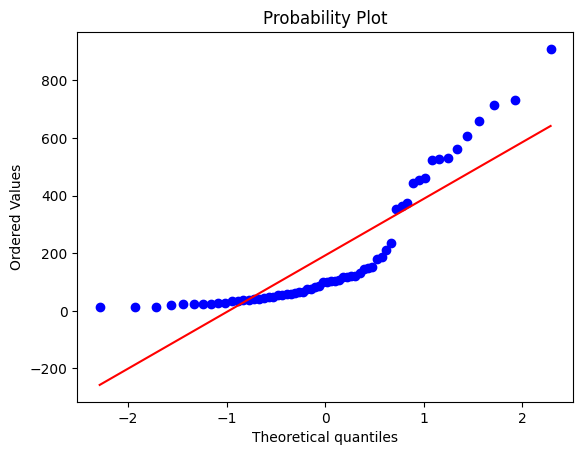

In [36]:
sts.probplot(first_merge['AvlBeds'], dist="norm", plot=plt) # Distribution of AvlBeds is skewed right

Perform a Shapiro-Wilk test on those three variables; do your test results coincide with the QQ plots?

In [37]:
sts.shapiro(first_merge.NoFTE) # The ShapiroResult confirms the results of the QQ plot. The p value is way below .05, resulting in rejecting the null hypothesis of normality.

ShapiroResult(statistic=np.float64(0.6405450434116506), pvalue=np.float64(4.713089086036429e-11))

In [38]:
sts.shapiro(first_merge.OperRev) # The ShapiroResult confirms the results of the QQ plot. The p value is way below .05, resulting in rejecting the null hypothesis of normality.

ShapiroResult(statistic=np.float64(0.6164142894657201), pvalue=np.float64(1.842824884443753e-11))

In [39]:
sts.shapiro(first_merge.AvlBeds) # The ShapiroResult confirms the results of the QQ plot. The p value is way below .05, resulting in rejecting the null hypothesis of normality.

ShapiroResult(statistic=np.float64(0.7571576432169286), pvalue=np.float64(9.06532237947973e-09))

### References
* DeanWilson406. (n.d.). 07 Independent Lab Dean Wilson (2) [Jupyter Notebook]. GitHub. Retrieved April 28, 2025, from https://github.com/DeanWilson406/week7labs/blob/main/07_Independent_Lab_Dean_Wilson%20(2).ipynb

* DeanWilson406. (n.d.). 08 Independent Lab Dean Wilson [Jupyter Notebook]. GitHub. Retrieved April 28, 2025, from https://github.com/DeanWilson406/week8labs/blob/main/08_Independent_Lab_Dean_Wilson.ipynb

* OpenAI. (2025, April 28). ChatGPT conversation share link [AI conversation]. ChatGPT. Retrieved from https://chatgpt.com/share/681027a8-5e80-8001-bbac-1cedc1ff07f6

* Inch Calculator. (n.d.). Scientific notation calculator. Retrieved April 28, 2025, from https://www.inchcalculator.com/scientific-notation-calculator/